In [1]:
# 对收集好数据进行缺失率计算，留下缺失率小于50%的数据，保存P1.csv
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('./wenjian/S18.csv')

# 计算每一列的缺失率，排除第一列
missing_data = df.iloc[:, 1:].isnull().mean()

# 保存缺失率数据到新的 CSV 文件
# missing_data.to_csv('queshilv.csv', index_label='subject_id', header=['deletionrate'])

# 输出每一列的缺失率
print("每一列的缺失率：")
print(missing_data)

# 过滤出缺失率大于 50% 的列名
columns_to_delete = missing_data[missing_data > 0.5].index

# 删除缺失率大于 50% 的列
df_filtered = df.drop(columns=columns_to_delete)

# 输出处理后的数据框架
print("\n处理后的数据框架：")
print(df_filtered)
df_filtered.to_csv('P1.csv')

# 删除给药方式IV
# 在使用机器学习模型时，需要确保所有特征都是数值型的，因为模型无法处理字符串类型的数据。
# race列：WHITE:0 OTHER:1
# gender列：female:0 male:1

每一列的缺失率：
value                     0.000000
gender                    0.000000
age                       0.000000
race                      0.000000
weight                    0.000000
                            ...   
AbsoluteCount-Eos         0.763118
AbsoluteCount-Basos       0.763118
AT(Antithrombinfunct)     0.992504
UFHeparin(Anti-Xa)        0.986507
Creatinine(wholeblood)    0.992504
Length: 105, dtype: float64

处理后的数据框架：
     subject_id  value  gender  age     race  weight  height  drinking  \
0             1    2.7       0   56    WHITE    74.0   170.0       0.0   
1             1    3.9       0   56    WHITE    74.0   170.0       0.0   
2             2    0.7       1   57    WHITE    97.9   173.0       0.0   
3             2    0.5       1   57    WHITE    77.5   173.0       0.0   
4             2    1.0       1   57    WHITE    77.5   173.0       0.0   
..          ...    ...     ...  ...      ...     ...     ...       ...   
662         259    1.0       0   64    WHITE   11

In [19]:
# 在P1.csv文件基础上处理异常值，保存P2.csv
import pandas as pd

data = pd.read_csv('./wenjian1/P1.csv')

# 对所有列进行描述性统计
description = data.describe(include='all')

# 转置描述性统计结果
description = description.transpose()

# print(description)
# 
# description.to_csv('description_P1.csv')

# 通过最大值可以看出具有异常值的列为：value、ArterialBaseExcess、Prothrombintime、INR
# 将异常数值修改为其中位数：2.2、0.0、15.0、1.3
# 将处理完异常值后的文件重命名为P2.csv

# 再次通过描述性统计查看修改的异常值是否正确
data1 = pd.read_csv('./wenjian1/P2.csv')

# 对所有列进行描述性统计
description1 = data1.describe(include='all')

# 转置描述性统计结果
description1 = description1.transpose()

print(description1)

                        count        mean         std     min      25%  \
subject_id              667.0  126.982009   77.778018   1.000   55.500   
value                   667.0    3.626987   10.159161   0.300    1.100   
gender                  667.0    0.584708    0.493142   0.000    0.000   
age                     667.0   56.628186   15.691173  23.000   47.500   
race                    667.0    0.350825    0.477586   0.000    0.000   
...                       ...         ...         ...     ...      ...   
Prothrombintime         655.0   17.872672    8.732482  10.300   13.700   
PTT                     650.0   43.999231   26.964492  21.000   28.900   
INR                     655.0    1.642137    0.910655   0.900    1.200   
Fibrinogen              424.0  398.053066  201.671292  73.000  228.000   
SpecificGravity(urine)  449.0    1.017927    0.008348   1.002    1.012   

                            50%      75%      max  
subject_id              130.000  195.000   262.00  
value  

In [ ]:
# 在P2.csv文件基础上，进行数据的描述性统计、缺失率计算、正态性检验、绘制散点图
import pandas as pd
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import os

# 读取 CSV 文件
df = pd.read_csv('./wenjian/P2.csv')

# 将第一列数据设置为索引列
df.set_index(df.columns[0], inplace=True)

# 计算每列的缺失率
missing_rate = df.isnull().mean()

# 将'gender'、'race'和'drinking'列的数据类型转换为object
cols_to_convert = ['gender', 'race', 'drinking', 'doses_per_24_hrs']
df[cols_to_convert] = df[cols_to_convert].astype('object')

# 选择连续变量列进行计算
continuous_vars = df.select_dtypes(include=['float64', 'int64'])
# 计算中位数和四分位距
q1s = continuous_vars.quantile(0.25)
q2s = continuous_vars.quantile(0.5)
q3s = continuous_vars.quantile(0.75)
# 创建一个新的DataFrame来存储输出结果
output_data = []
# 格式化输出每一列的结果
for col in continuous_vars.columns:
    q1 = q1s[col]
    q2 = q2s[col]
    q3 = q3s[col]
    output = "{:.2f} ({:.2f}-{:.3f})".format(q2, q1, q3)
    missing = "{:.3f}".format(missing_rate[col])
    
    # 正态性检验
    stat, p = shapiro(df[col].dropna())
    if p > 0.05:
        normality_result = "Normally distributed"
    else:
        normality_result = "Not normally distributed"
    
    print(f"{col}: {output} {missing} Normality: {normality_result}")
    output_data.append([col, output, missing, normality_result])

# 选择分类变量列进行计算
categorical_vars = df.select_dtypes(include=['object'])

for col in categorical_vars.columns:
    zeros_count = (categorical_vars[col] == 1).sum()
    total_count = len(categorical_vars[col])
    zeros_percentage = (zeros_count / total_count) * 100
    missing = "{:.3f}".format(missing_rate[col])
    print(f"{col}: {zeros_count} ({zeros_percentage:.3f}%) {missing}")
    output_data.append([col, f"{zeros_count} ({zeros_percentage:.3f}%)", missing])

# 创建DataFrame并保存到CSV文件
output_df = pd.DataFrame(output_data, columns=['Column', 'Output', 'Missing Rate', 'Normality'])
output_df.to_csv('biaoxian1.csv', index=False)

# # 获取缺失率大于0%的列名
# cols_with_missing_values = missing_rate[missing_rate > 0].index
# # 绘制缺失率大于0%的列的散点图
# for col in cols_with_missing_values:
#     plt.figure(figsize=(8, 6))
#     plt.scatter(df.index, df[col], alpha=0.5)
#     plt.xlabel("Index")
#     plt.ylabel(col)
#     plt.title(f"Scatter plot of {col}")
#     plt.grid(True)
#     # 指定保存路径为"./wenjian/biaoxian1"文件夹
#     save_folder = "./wenjian/biaoxian1"
#     os.makedirs(save_folder, exist_ok=True)  # 创建保存文件夹，如果不存在则创建
#     # 文件名，假设 col 包含文件名
#     file_name = f"{col}_scatter.png"
#     # 保存散点图为 PNG 文件
#     plt.savefig(os.path.join(save_folder, file_name))
#     plt.show()

In [20]:
# 使用均值填充缺失率小于5%的数据列（6列），保存P3.csv
# 计算P2.csv文件的缺失率
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('./wenjian1/P2.csv')

# 计算每一列的缺失率，排除第一列
# missing_data = df.iloc[:, 1:].isnull().mean()

# print(missing_data)
# 保存缺失率数据到新的 CSV 文件
# missing_data.to_csv('queshilv.csv', index_label='subject_id', header=['deletionrate'])

# 对于缺失率小于5%数据列（'Magnesium', 'Phosphorous', 'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT'）用其均值填充
# 指定需要处理的列
columns_to_fill = ['Magnesium', 'Phosphorous', 'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT']

# 使用均值填充缺失值
df[columns_to_fill] = df[columns_to_fill].fillna(df[columns_to_fill].mean())

# 保存填充后的数据到新文件
df.to_csv('P3.csv', index=False)

# 计算填充后的缺失率，排除第一列
missing_data1 = df.iloc[:, 1:].isnull().mean()

print(missing_data1)

# 保存缺失率数据到新的 CSV 文件
# missing_data1.to_csv('queshilv.csv', index_label='subject_id', header=['deletionrate'])

value                     0.000000
gender                    0.000000
age                       0.000000
race                      0.000000
weight                    0.000000
                            ...   
Prothrombintime           0.000000
PTT                       0.000000
INR                       0.000000
Fibrinogen                0.364318
SpecificGravity(urine)    0.326837
Length: 61, dtype: float64


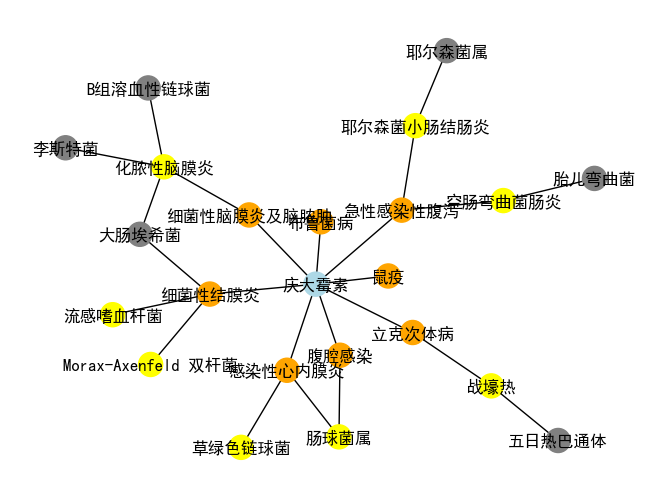

In [26]:
# 通过《指南》对患者进行分类 感染/非感染：230/32
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# 创建包含4个连接的DataFrame
df = pd.DataFrame({
    'from': ['庆大霉素', '急性感染性腹泻', '空肠弯曲菌肠炎', '庆大霉素', '急性感染性腹泻', '耶尔森菌小肠结肠炎', '庆大霉素', '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '庆大霉素', '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '庆大霉素', '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '庆大霉素', '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '庆大霉素', '感染性心内膜炎', '庆大霉素', '感染性心内膜炎', '庆大霉素', '腹腔感染', '庆大霉素', '细菌性结膜炎', '庆大霉素', '细菌性结膜炎', '庆大霉素', '细菌性结膜炎', '庆大霉素', '立克次体病', '战壕热', '庆大霉素', '庆大霉素'],
    'to': ['急性感染性腹泻', '空肠弯曲菌肠炎', '胎儿弯曲菌', '急性感染性腹泻', '耶尔森菌小肠结肠炎', '耶尔森菌属', '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', 'B组溶血性链球菌',  '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '大肠埃希菌',  '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '李斯特菌',  '细菌性脑膜炎及脑脓肿', '化脓性脑膜炎', '李斯特菌', '感染性心内膜炎', '草绿色链球菌', '感染性心内膜炎', '肠球菌属', '腹腔感染', '肠球菌属', '细菌性结膜炎', '流感嗜血杆菌', '细菌性结膜炎', 'Morax-Axenfeld 双杆菌', '细菌性结膜炎', '大肠埃希菌', '立克次体病', '战壕热',  '五日热巴通体', '鼠疫', '布鲁菌病']
})

# 创建图形
G = nx.from_pandas_edgelist(df, 'from', 'to')

# 使用kamada_kawai_layout布局算法来确定节点的位置，以使绘制出的线不交叉
pos = nx.kamada_kawai_layout(G)

# 使用广度优先搜索算法来标记不同级别的子节点
def mark_subtree_levels(G, root):
    levels = {}
    queue = deque([(root, 0)])  # 根节点的级别为0
    while queue:
        node, level = queue.popleft()
        levels[node] = level
        for neighbor in G.neighbors(node):
            if neighbor not in levels:
                queue.append((neighbor, level + 1))
    return levels

# 标记子节点的级别
subtree_levels = mark_subtree_levels(G, '庆大霉素')

# 根据子节点级别设置节点颜色
node_color = []
for node in G.nodes():
    if node == '庆大霉素':
        node_color.append('lightblue')  # 主节点为浅蓝色
    elif subtree_levels[node] == 1:
        node_color.append('orange')  # 一级子节点为橙色，一般为疾病
    elif subtree_levels[node] == 2:
        node_color.append('yellow')  # 二级子节点为黄色，一般为疾病
    elif subtree_levels[node] == 3:
        node_color.append('grey')  # 三级子节点为灰色，一般为病原

# 绘制图形
nx.draw(G, pos, with_labels=True, font_family='SimHei', node_color=node_color)

# 显示图形
plt.show()


In [31]:
# 通过分类结果在P3.csv文件最后加一列 type 感染/非感染：0/1（230/32）
# 先通过S17.csv把患者ID复制到P3文件，根据ID将患者进行分类，感染数据/非感染数据：619/48
import pandas as pd

# 读取CSV文件
df = pd.read_csv('./wenjian1/P3.csv')

# 给定的 subject_id 列表
subject_ids = [
    '10035168', '10036086', '10104674', '10213338', '10236942', '10332371', '10344684', '10524082', 
    '10884861', '10390732', '10471469', '10950205', '11022245', '11025155', '11098660', '11101925', 
    '11106897', '11180585', '10641937', '11005836', '11165060', '11234592', '11239107', '11235409', 
    '11262894', '11281568', '11241014', '11269805', '11326206', '11494804', '11317682', '11551024', 
    '11599567', '11488234', '11518898', '11560010', '11658100', '11652327', '11714491', '11676215', 
    '11822710', '11857478', '11885384', '11891514', '12237223', '11986924', '12001921', '12006413', 
    '12152082', '11697323', '11863409', '11972365', '12072445', '12152630', '12173207', '12249666', 
    '12325110', '12361374', '12403858', '12476201', '12453404', '12502618', '12648313', '12679321', 
    '12695987', '12758388', '12828636', '12943458', '13031833', '13060785', '13207574', '12116228', 
    '12231709', '12288039', '12526165', '12725946', '12749902', '12932366', '12963394', '13024904', 
    '13299333', '13331269', '13496639', '13509204', '13315366', '13365915', '13502256', '13347662', 
    '13390728', '13696506', '13792604', '13777050', '14025287', '14065397', '14105983', '14146400', 
    '14164281', '14257483', '14266723', '14275781', '14280192', '13751677', '13752054', '13798658', 
    '13915169', '14155916', '14189406', '14378086', '14420248', '14343405', '14371035', '14464933', 
    '14702275', '14742438', '14446260', '14689985', '14734813', '14759585', '14829515', '15031785', 
    '14886080', '14916430', '15102490', '15198026', '15221724', '15237577', '15305912', '14834589', 
    '15035666', '15062911', '15094735', '15175429', '15344483', '15415643', '15452777', '15610823', 
    '15354831', '15567127', '15573773', '15637902', '15689523', '15701699', '15349413', '15573438', 
    '15782904', '15953468', '16308768', '15795343', '15850072', '16002684', '16024297', '16092373', 
    '16147199', '16164098', '16238322', '16259359', '16296621', '16399965', '16504173', '16251948', 
    '16330993', '16513166', '16492756', '16528007', '16560909', '17060455', '16736626', '17006856', 
    '16509298', '16534660', '16654740', '16987387', '17165725', '17233058', '17020722', '17201534', 
    '17302319', '17336353', '17401129', '17172316', '17417573', '17399295', '17552934', '17651038', 
    '17806475', '17444849', '17597709', '17851873', '17852478', '19038726', '17880254', '18152000', 
    '18439036', '18455402', '18686090', '18833621', '18895046', '18898692', '17447711', '17739472', 
    '18018626', '18075452', '18091813', '18148412', '18228802', '18531225', '18721100', '18975498', 
    '19199702', '19373075', '19106423', '19122448', '19210530', '18939639', '19055392', '19336521', 
    '19890030', '19442119', '19509298', '19559421', '19589533', '19687015', '19711171', '19830694', 
    '19844373', '19965582', '19970491', '19985293', '19547502', '19929286'
]

# 创建新的type列，标记默认值为1
df['type'] = 1

# 对于在subject_ids列表中的subject_id，标记为0
df.loc[df['subject_id'].astype(str).isin(subject_ids), 'type'] = 0

# 保存更新后的DataFrame到新的CSV文件
# df.to_csv('P4.csv', index=False)

# 显示前几行以检查
print(df.head())

# P4.csv中subject_id改为序号

# 创建一个字典来存储每个不同的 "subject_id" 对应的序号
subject_id_mapping = {}
new_subject_ids = []

# 遍历数据集，为每个不同的 "subject_id" 分配一个唯一的序号
current_id = 1
for subject_id in df['subject_id']:
    if subject_id not in subject_id_mapping:
        subject_id_mapping[subject_id] = current_id
        current_id += 1
    new_subject_ids.append(subject_id_mapping[subject_id])

# 将 "subject_id" 列替换为新的序号
df['subject_id'] = new_subject_ids

# 保存修改后的数据到新文件
df.to_csv('P4.csv', index=False)
print(df)

   subject_id  value  gender  age  race  weight  height  drinking  \
0    10035168    2.7       0   56     0    74.0   170.0       0.0   
1    10035168    3.9       0   56     0    74.0   170.0       0.0   
2    10036086    0.7       1   57     0    97.9   173.0       0.0   
3    10036086    0.5       1   57     0    77.5   173.0       0.0   
4    10036086    1.0       1   57     0    77.5   173.0       0.0   

   dose_val_rx  doses_per_24_hrs  ...  Potassium(serum)  HCO3(serum)  \
0          120                 3  ...               3.6           20   
1          100                 3  ...               3.1           19   
2          120                 1  ...               4.2           28   
3          100                 1  ...               3.8           25   
4          100                 1  ...               3.7           23   

   PlateletCount  Potassium(wholeblood)  Prothrombintime   PTT  INR  \
0             32                    4.7             13.8  26.7  1.1   
1         

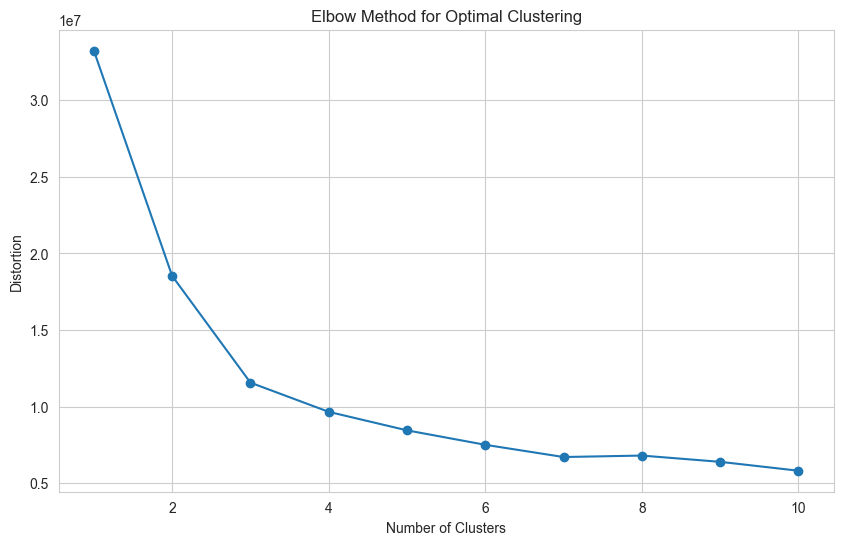

In [33]:
# 对于感染患者（type:0）使用肘部法确定kmeans聚类的k值
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 读取CSV文件
data = pd.read_csv('./wenjian1/P4.csv')

# 选择要进行聚类的特定列：缺失率为0，且不包含分类变量（'gender','race','drinking','doses_per_24_hrs'）
selected_columns = ['value', 'weight', 'dose_val_rx', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'HT', 'Hemoglobin', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'Sodium(serum)', 'Aniongap', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Magnesium', 'Phosphorous', 'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT']
# selected_data = data[selected_columns]

# 筛选 type 为 0 的数据行
filtered_data = data[data['type'] == 0]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 使用肘部法确定最佳的聚类数
distortions = []
K_range = range(1, 11)  # 尝试不同的聚类数
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(selected_data)
    distortions.append(kmeans.inertia_)  # 计算每个聚类数的畸变程度

# 绘制肘部法图像
plt.figure(figsize=(10, 6))
plt.plot(K_range, distortions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method for Optimal Clustering')
plt.show()


In [43]:
# 对于感染患者（type:0）进行kmeans聚类，将聚类结果保存为label1列
import pandas as pd
from sklearn.cluster import KMeans

# 读取CSV文件
data = pd.read_csv('./wenjian1/P4.csv')

# 选择要进行聚类的特定列
selected_columns = [
    'value', 'weight', 'dose_val_rx', 'day', 'duration', 'interval', 'sample',
    'creatinine', 'BUN', 'HT', 'Hemoglobin', 'WBC', 'Chloride(serum)',
    'Glucose(serum)', 'Sodium(serum)', 'Aniongap', 'Potassium(serum)',
    'HCO3(serum)', 'PlateletCount', 'Magnesium', 'Phosphorous',
    'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT'
]

# 筛选 type 为 0 的数据行
filtered_data = data[data['type'] == 0]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 聚成3类
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(selected_data)
cluster_labels = kmeans.labels_

# 创建一个新列存储聚类标签
filtered_data = filtered_data.copy()
filtered_data['label1'] = cluster_labels

# 将聚类标签合并回原始数据集中
# 确保只对 type 为 0 的行添加聚类标签，防止重复
data.loc[filtered_data.index, 'label1'] = filtered_data['label1']

# 将包含所有列数据的DataFrame保存为CSV文件
data.to_csv('P5.csv', index=False, encoding='utf-8')

print("聚类结果已保存到 P5.csv 文件中")


聚类结果已保存到 P5.csv 文件中


In [45]:
# 对于感染患者（type:0）根据label1列计算每组缺失率
import pandas as pd

# 读取P4.csv文件
data = pd.read_csv('./wenjian1/P5.csv')

# 根据'label'列将数据分为三组
group1 = data[data['label1'] == 0]
group2 = data[data['label1'] == 1]
group3 = data[data['label1'] == 2]

# 计算每组数据每一列的缺失率
missing_rate_group1 = group1.isnull().mean()
missing_rate_group2 = group2.isnull().mean()
missing_rate_group3 = group3.isnull().mean()

# 打印出缺失率
print("Missing Rates for Group 1:")
print(missing_rate_group1)

print("\nMissing Rates for Group 2:")
print(missing_rate_group2)

print("\nMissing Rates for Group 3:")
print(missing_rate_group2)

# 创建包含缺失率结果的DataFrame
missing_rates_df = pd.DataFrame({
    'Group 1 Missing Rate': missing_rate_group1,
    'Group 2 Missing Rate': missing_rate_group2,
    'Group 3 Missing Rate': missing_rate_group3
})

# 将结果保存到queshilv.csv文件中
missing_rates_df.to_csv('queshilv.csv')

print("缺失率结果已保存到 queshilv.csv 文件中。")

Missing Rates for Group 1:
subject_id                0.000000
value                     0.000000
gender                    0.000000
age                       0.000000
race                      0.000000
                            ...   
INR                       0.000000
Fibrinogen                0.496644
SpecificGravity(urine)    0.308725
type                      0.000000
label1                    0.000000
Length: 64, dtype: float64

Missing Rates for Group 2:
subject_id                0.000000
value                     0.000000
gender                    0.000000
age                       0.000000
race                      0.000000
                            ...   
INR                       0.000000
Fibrinogen                0.291391
SpecificGravity(urine)    0.198675
type                      0.000000
label1                    0.000000
Length: 64, dtype: float64

Missing Rates for Group 3:
subject_id                0.000000
value                     0.000000
gender                 

In [91]:
# 对于感染患者（type:0）根根据kmeans聚类结果分别用其均值填充，保存为P6.csv文件
import pandas as pd
from scipy.stats import shapiro

# 读取P4.csv文件
data = pd.read_csv('./wenjian1/P5.csv')

# 需要填充缺失值的列
columns_to_fill = ['LacticAcid', 'Glucosefingerstick(range70-100)', 'ALT', 'AST', 'AlkalinePhosphate', 'total_BL',
                   'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos',
                   'Differential-Neuts', 'PH(Arterial)', 'ArterialO2pressure', 'ArterialCO2Pressure',
                   'ArterialBaseExcess', 'TCO2(calc)Arterial', 'IonizedCalcium', 'LDH', 'albumin', 'height',
                   'PH(dipstick)', 'SpecificGravity(urine)', 'Fibrinogen', 'Potassium(wholeblood)',
                   'ArterialO2Saturation', 'Glucose(wholeblood)', 'Differential-Bands', 'CK(CPK)',
                   'Differential-Atyps', 'Troponin-T', 'PH(Venous)']

# # 进行K均值聚类，假设聚类数为3
# kmeans = KMeans(n_clusters=3, random_state=0).fit(data[columns_to_fill])
# data['label'] = kmeans.labels_

# 根据'Label1'列将数据分为三组
grouped = data.groupby('label1')

# 对每组数据进行缺失值填充
for group_name, group_data in grouped:
    mean_values = group_data[columns_to_fill].mean()
    
    # # 打印出每组变量分别添加的均值
    # print(f"Group {group_name} Mean Values:")
    # print(mean_values)
    
    data.loc[data['label1'] == group_name, columns_to_fill] = data.loc[data['label1'] == group_name, columns_to_fill].fillna(mean_values)

# 更新原始P6.csv文件
data.round(3).to_csv('P6.csv', index=False)

print(data)
# 
# # 提取标签列和所有其他变量
# label_col = 'label'
# variables = data.columns.difference([label_col])
# 
# # 初始化结果字典
# results = {label: {} for label in data[label_col].unique()}
# 
# # 对每个变量和每个标签组进行正态性检验
# for label in results:
#     group_data = data[data[label_col] == label]
#     for var in variables:
#         stat, p_value = shapiro(group_data[var].dropna())
#         results[label][var] = {'W-statistic': stat, 'p-value': p_value}
# 
# # 转换结果为DataFrame
# results_df = pd.DataFrame(results).T
# 
# # 打印和保存结果
# print(results_df)
# results_df.to_csv('normality_test_results.csv')
# 
# # 计算填充后的缺失率，排除第一列
# missing_data = data.iloc[:, 1:].isnull().mean()
# 
# # print(missing_data)
# 
# # 保存缺失率数据到新的 CSV 文件
# missing_data.to_csv('queshilv.csv', index_label='subject_id', header=['deletionrate'])

     subject_id  value  gender  age  race  weight      height  drinking  \
0             1    2.7       0   56     0    74.0  170.000000       0.0   
1             1    3.9       0   56     0    74.0  170.000000       0.0   
2             2    0.7       1   57     0    97.9  173.000000       0.0   
3             2    0.5       1   57     0    77.5  173.000000       0.0   
4             2    1.0       1   57     0    77.5  173.000000       0.0   
..          ...    ...     ...  ...   ...     ...         ...       ...   
662         259    1.0       0   64     0   113.0  169.944444       0.0   
663         260    3.7       1   55     0    58.1  178.000000       0.0   
664         261    2.0       1   55     0    58.3  173.943925       0.0   
665         261    1.0       1   55     0    58.3  173.943925       0.0   
666         262    7.9       0   81     1   116.0  150.000000       0.0   

     dose_val_rx  doses_per_24_hrs  ...  HCO3(serum)  PlateletCount  \
0            120            

For n_clusters = 2, the average silhouette score is: 0.36312855749325873
For n_clusters = 3, the average silhouette score is: 0.26540349600634505
For n_clusters = 4, the average silhouette score is: 0.20316212361427977
For n_clusters = 5, the average silhouette score is: 0.28989918707193074
For n_clusters = 6, the average silhouette score is: 0.48696865093387387
For n_clusters = 7, the average silhouette score is: 0.5959489026642826
For n_clusters = 8, the average silhouette score is: 0.6868096047102829
For n_clusters = 9, the average silhouette score is: 0.8428863860417065
For n_clusters = 10, the average silhouette score is: 0.9579570026096683
For n_clusters = 11, the average silhouette score is: 0.9858642972536349
For n_clusters = 12, the average silhouette score is: 1.0


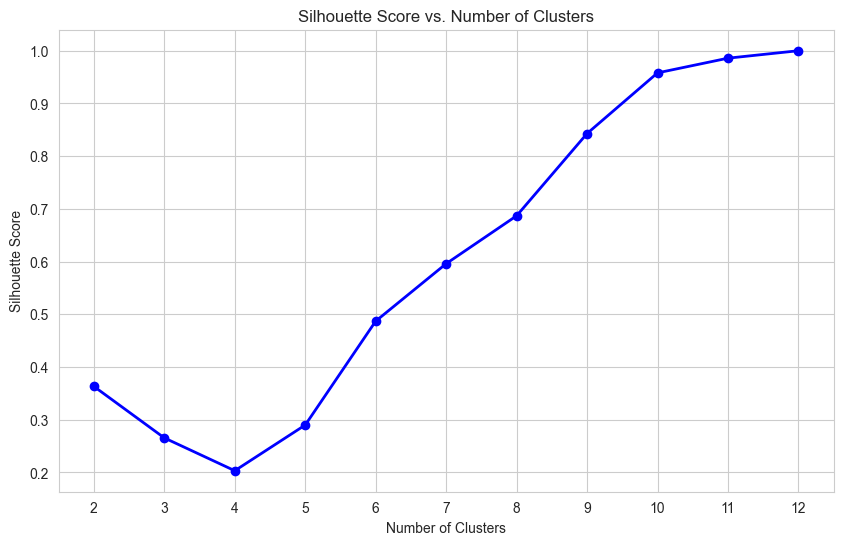

In [82]:
# 对于感染患者（type:0）的分类变量使用轮廓系数法确定kmodes聚类的k值
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes

# 读取CSV文件
data = pd.read_csv('./wenjian1/P6.csv')

# 选择要进行聚类的特定列：缺失率为0的分类变量，且不包含drinking
selected_columns = ['gender','race', 'doses_per_24_hrs']
# selected_data = data[selected_columns]

# 筛选 type 为 0 的数据行
filtered_data = data[data['type'] == 0]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 初始化一个空列表来存储每个聚类数量对应的轮廓系数
silhouette_scores = []

# 尝试不同的聚类数量
for k in range(2, 13):
    # 初始化KModes模型
    km = KModes(n_clusters=k, init='Cao', n_init=1, verbose=0)
    
    # 对数据进行聚类
    labels = km.fit_predict(selected_data)
    
    # 计算轮廓系数
    score = silhouette_score(selected_data, labels, metric='hamming')  # 使用Hamming距离
    silhouette_scores.append(score)
    
    # 打印每个聚类数量对应的轮廓系数
    print(f"For n_clusters = {k}, the average silhouette score is: {score}")

# 绘制轮廓系数随聚类数变化的折线图
plt.figure(figsize=(10, 6))
plt.plot(range(2, 13), silhouette_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xticks(range(2, 13))
plt.grid(True)
plt.show()

In [57]:
# 对于感染患者（type:0）的分类变量使用kmodes进行聚类
import pandas as pd
from kmodes.kmodes import KModes

# 读取CSV文件
data = pd.read_csv('./wenjian1/P6.csv')

# 选择要进行聚类的特定列
selected_columns = ['gender', 'race', 'doses_per_24_hrs']

# 筛选 type 为 0 的数据行
filtered_data = data[data['type'] == 0]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 使用 KModes 聚类
kmodes = KModes(n_clusters=12, init='Huang', n_init=5, random_state=42)
cluster_labels = kmodes.fit_predict(selected_data)

# 创建一个新列存储聚类标签
filtered_data = filtered_data.copy()
filtered_data['cluster1'] = cluster_labels

# 将聚类标签合并回原始数据集中
# 确保只对 type 为 0 的行添加聚类标签，防止重复
data.loc[filtered_data.index, 'cluster1'] = filtered_data['cluster1']

# 将包含所有列数据的DataFrame保存为CSV文件
data.to_csv('P7.csv', index=False, encoding='utf-8')

print("聚类结果已保存到 P7.csv 文件中")


聚类结果已保存到 P7.csv 文件中


In [73]:
import pandas as pd
from kmodes.kmodes import KModes

# 读取P7.csv文件
data = pd.read_csv('./wenjian1/P7.csv')

# 需要填充缺失值的列
columns_to_fill = ['drinking']

# 筛选出type为0的感染患者
filtered_data = data[data['type'] == 0]

# 根据'cluster1'列将数据分为组
grouped = filtered_data.groupby('cluster1')

# 对每组数据进行缺失值填充
for group_name, group_data in grouped:
    mode_values = group_data[columns_to_fill].mode().iloc[0]
    data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill] = data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill].fillna(mode_values[0])

# 将结果保存P8.csv文件
data.to_csv('P8.csv', index=False)

print("缺失值填充结果已保存到 P8.csv 文件中")


缺失值填充结果已保存到 P8.csv 文件中


C:\Windows\Temp\ipykernel_16304\3463016940.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill] = data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill].fillna(mode_values[0])
C:\Windows\Temp\ipykernel_16304\3463016940.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill] = data.loc[(data['type'] == 0) & (data['cluster1'] == group_name), columns_to_fill].fillna(mode_values[0])
C:\Windows\Temp\ipykernel_16304\3463016940.py:19: Futu

In [74]:
# 对P8.csv文件进行描述性统计
import pandas as pd

data = pd.read_csv('./wenjian1/P8.csv')

# 对所有列进行描述性统计
description = data.describe(include='all')

# 转置描述性统计结果
description = description.transpose()

print(description)

# description.to_csv('description_P7.csv')

                        count        mean         std     min      25%  \
subject_id              667.0  126.982009   77.778018   1.000   55.500   
value                   667.0    3.626987   10.159161   0.300    1.100   
gender                  667.0    0.584708    0.493142   0.000    0.000   
age                     667.0   56.628186   15.691173  23.000   47.500   
race                    667.0    0.350825    0.477586   0.000    0.000   
...                       ...         ...         ...     ...      ...   
Fibrinogen              639.0  403.512833  166.082162  73.000  292.000   
SpecificGravity(urine)  645.0    1.017623    0.007009   1.002    1.014   
type                    667.0    0.071964    0.258622   0.000    0.000   
label1                  619.0    1.274637    0.825672   0.000    1.000   
cluster1                619.0    4.271405    2.670225   0.000    2.000   

                            50%      75%      max  
subject_id              130.000  195.000   262.00  
value  

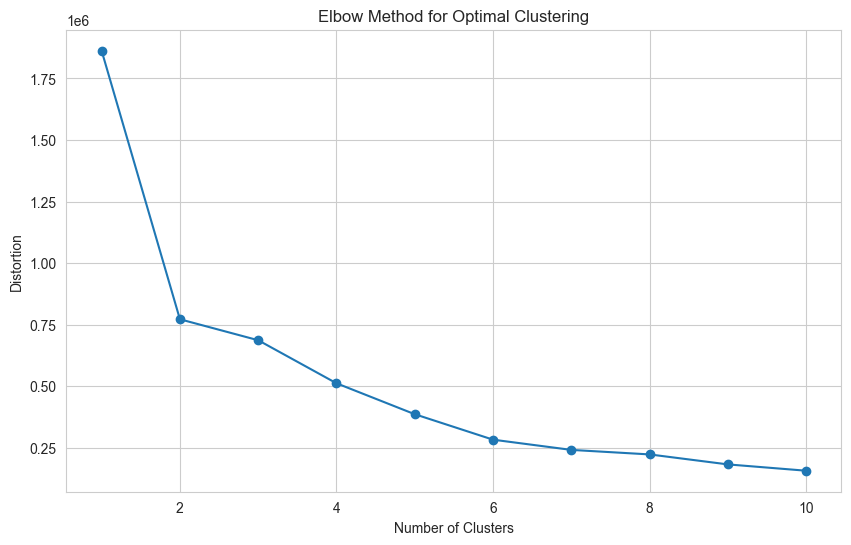

In [83]:
# 对于非感染患者（type:1）使用肘部法确定kmeans聚类的k值
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 读取CSV文件
data = pd.read_csv('./wenjian1/P8.csv')

# 选择要进行聚类的特定列：缺失率为0，且不包含分类变量（'gender','race','drinking','doses_per_24_hrs'）
selected_columns = ['value', 'weight', 'dose_val_rx', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'HT', 'Hemoglobin', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'Sodium(serum)', 'Aniongap', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Magnesium', 'Phosphorous', 'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT']
# selected_data = data[selected_columns]

# 筛选 type 为 1 的数据行
filtered_data = data[data['type'] == 1]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 使用肘部法确定最佳的聚类数
distortions = []
K_range = range(1, 11)  # 尝试不同的聚类数
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(selected_data)
    distortions.append(kmeans.inertia_)  # 计算每个聚类数的畸变程度

# 绘制肘部法图像
plt.figure(figsize=(10, 6))
plt.plot(K_range, distortions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion') 
plt.title('Elbow Method for Optimal Clustering')
plt.show()


In [92]:
# 对于非感染患者（type:1）进行kmeans聚类，将聚类结果保存为label2列
import pandas as pd
from sklearn.cluster import KMeans

# 读取CSV文件
data = pd.read_csv('./wenjian1/P8.csv')

# 选择要进行聚类的特定列
selected_columns = [
    'value', 'weight', 'dose_val_rx', 'day', 'duration', 'interval', 'sample',
    'creatinine', 'BUN', 'HT', 'Hemoglobin', 'WBC', 'Chloride(serum)',
    'Glucose(serum)', 'Sodium(serum)', 'Aniongap', 'Potassium(serum)',
    'HCO3(serum)', 'PlateletCount', 'Magnesium', 'Phosphorous',
    'Calciumnon-ionized', 'Prothrombintime', 'INR', 'PTT'
]

# 筛选 type 为 0 的数据行
filtered_data = data[data['type'] == 1]

# 选择特定列的数据
selected_data = filtered_data[selected_columns]

# 聚成3类
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(selected_data)
cluster_labels = kmeans.labels_

# 创建一个新列存储聚类标签
filtered_data = filtered_data.copy()
filtered_data['label2'] = cluster_labels

# 将聚类标签合并回原始数据集中
# 确保只对 type 为 0 的行添加聚类标签，防止重复
data.loc[filtered_data.index, 'label2'] = filtered_data['label2']

# 将包含所有列数据的DataFrame保存为CSV文件
data.to_csv('P9.csv', index=False, encoding='utf-8')

print("聚类结果已保存到 P9.csv 文件中")


聚类结果已保存到 P9.csv 文件中


In [93]:
# 对于非感染患者（type:1）根根据kmeans聚类结果分别用其均值填充，保存为P10.csv文件
import pandas as pd
from scipy.stats import shapiro

# 读取P4.csv文件
data = pd.read_csv('./wenjian1/P9.csv')

# 需要填充缺失值的列
columns_to_fill = ['LacticAcid', 'Glucosefingerstick(range70-100)', 'ALT', 'AST', 'AlkalinePhosphate', 'total_BL',
                   'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos',
                   'Differential-Neuts', 'PH(Arterial)', 'ArterialO2pressure', 'ArterialCO2Pressure',
                   'ArterialBaseExcess', 'TCO2(calc)Arterial', 'IonizedCalcium', 'LDH', 'albumin', 'height',
                   'PH(dipstick)', 'SpecificGravity(urine)', 'Fibrinogen', 'Potassium(wholeblood)',
                   'ArterialO2Saturation', 'Glucose(wholeblood)', 'Differential-Bands', 'CK(CPK)',
                   'Differential-Atyps', 'Troponin-T', 'PH(Venous)']

# # 进行K均值聚类，假设聚类数为3
# kmeans = KMeans(n_clusters=3, random_state=0).fit(data[columns_to_fill])
# data['label'] = kmeans.labels_

# 根据'Label'列将数据分为三组
grouped = data.groupby('label2')

# 对每组数据进行缺失值填充
for group_name, group_data in grouped:
    mean_values = group_data[columns_to_fill].mean()
    
    # # 打印出每组变量分别添加的均值
    # print(f"Group {group_name} Mean Values:")
    # print(mean_values)
    
    data.loc[data['label2'] == group_name, columns_to_fill] = data.loc[data['label2'] == group_name, columns_to_fill].fillna(mean_values)

# 更新原始P6.csv文件
data.round(3).to_csv('P10.csv', index=False)

print(data)


     subject_id  value  gender  age  race  weight   height  drinking  \
0             1    2.7       0   56     0    74.0  170.000       0.0   
1             1    3.9       0   56     0    74.0  170.000       0.0   
2             2    0.7       1   57     0    97.9  173.000       0.0   
3             2    0.5       1   57     0    77.5  173.000       0.0   
4             2    1.0       1   57     0    77.5  173.000       0.0   
..          ...    ...     ...  ...   ...     ...      ...       ...   
662         259    1.0       0   64     0   113.0  169.944       0.0   
663         260    3.7       1   55     0    58.1  178.000       0.0   
664         261    2.0       1   55     0    58.3  173.944       0.0   
665         261    1.0       1   55     0    58.3  173.944       0.0   
666         262    7.9       0   81     1   116.0  150.000       0.0   

     dose_val_rx  doses_per_24_hrs  ...  Potassium(wholeblood)  \
0            120                 3  ...                  4.700   
1  

In [94]:
# 对于非感染患者（type:1）的缺失分类变量直接使用众数填充
import pandas as pd

# 读取P10.csv文件
data = pd.read_csv('./wenjian1/P10.csv')

# 计算type为1的drinking列的众数
type_1_mode_drinking = data[data['type'] == 1]['drinking'].mode().iloc[0]

# 使用众数填充type为0的drinking列的缺失值
data.loc[(data['type'] == 1) & (data['drinking'].isnull()), 'drinking'] = type_1_mode_drinking

# 将结果保存到新的CSV文件
data.to_csv('P11.csv', index=False)

print("缺失值填充结果已保存到 P11.csv 文件中")


缺失值填充结果已保存到 P11.csv 文件中


In [95]:
import pandas as pd

# 读取P11.csv文件
df = pd.read_csv('./wenjian1/P11.csv')

# 计算每一列的缺失率，排除第一列
missing_data = df.iloc[:, 1:].isnull().mean()

# 保存缺失率数据到新的 CSV 文件
missing_data.to_csv('queshilv.csv', index_label='subject_id', header=['deletionrate'])

# 计算每一列缺失率
print(missing_data)

value                     0.000000
gender                    0.000000
age                       0.000000
race                      0.000000
weight                    0.000000
                            ...   
SpecificGravity(urine)    0.000000
type                      0.000000
label1                    0.071964
cluster1                  0.071964
label2                    0.928036
Length: 65, dtype: float64


In [ ]:
# 在P11.csv文件中删除label1、cluster1、label2，另存为P12.csv
# 现在数据中变量分为：人口统计学信息、庆大霉素信息、实验室监测指标
# 其中患者id：'subject_id'
# ①其中人口统计学信息包括：'gender', 'age', 'race', 'weight', 'height', 'drinking', 'type'
# ②其中庆大霉素信息包括：'value', 'dose', 'per24', 'day', 'duration', 'interval', 'sample'
# ③其中实验室检测指标包括：'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)'

# 分类变量为(5个)：'gender', 'race', 'drinking', 'type', 'per24'
# 连续变量为(57个)：'age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)'

In [8]:
# 1.数据处理部分-人口统计学资料
# 1.1连续变量表示为具有四分位距 （IQR） 的中位数。分类变量以计数和百分比 （%） 表示。
import pandas as pd

# 读取P13.csv文件
df = pd.read_csv('./wenjian1/P12.csv')

# 连续型变量列表
numeric_columns = ['age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)']

# 分类型列列表
categorical_columns = ['gender', 'race', 'drinking', 'type', 'per24']

# 计算数值型列的中位数和四分位距
numeric_stats = df[numeric_columns].describe().loc[['50%', '25%', '75%']]

# 计算分类型列中值为1的总个数和占比
categorical_ones_count = df[categorical_columns].eq(1).sum()
categorical_ones_percentage = (categorical_ones_count / len(df)) * 100

# 格式化输出结果
output_numeric = numeric_stats.apply(lambda x: f"{x['50%']} ({x['25%']}-{x['75%']})")

# 创建一个新的 DataFrame 来存储分类型列的个数和百分比
output_categorical = pd.DataFrame({
    '总个数': categorical_ones_count,
    '占比': categorical_ones_percentage
})

output_categorical['格式化'] = output_categorical.apply(lambda row: f"{row['总个数']} ({row['占比']:.2f}%)", axis=1)

# 打印结果
print("数值型列的中位数(四分位距):")
print(output_numeric)
print("\n分类型列中值为1的总个数(占比):")
print(output_categorical['格式化'])

# 将结果保存到DataFrame中
output_df = pd.DataFrame({'数值型列的中位数(四分位距)': output_numeric, '分类型列中值为1的总个数(占比)': output_categorical['格式化']})

# 保存结果到CSV文件
output_df.to_csv('shujuchuli.csv', index_label='Column')


数值型列的中位数(四分位距):
age                                               59.0 (47.5-67.0)
weight                                           77.0 (65.0-97.75)
height                                         170.0 (165.0-178.0)
value                                                2.2 (1.1-4.1)
dose                                            120.0 (80.0-300.0)
day                                                  2.0 (1.0-4.0)
duration                                           11.3 (7.0-23.6)
interval                                             0.0 (0.0-2.8)
sample                                               2.0 (1.0-4.0)
creatinine                                           1.1 (0.8-1.9)
BUN                                               24.0 (15.0-40.0)
albumin                                          2.598 (2.3-2.826)
ALT                                               29.0 (17.0-76.0)
AST                                              49.0 (26.0-103.0)
total_BL                                      

In [9]:
# 检验数据正态性
import pandas as pd
import scipy.stats as stats

# 读取CSV文件
df = pd.read_csv('./wenjian1/P12.csv')

# 去除第一列（假设第一列是索引或不需要检验的列）
# data = df.iloc[:, 1:]
clomns = ['age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)']
data = df[clomns]

# 存储正态性检验结果
results = {}

# 对每一列进行Shapiro-Wilk检验
for column in data.columns:
    col_data = data[column].dropna()  # 去除缺失值

    # Shapiro-Wilk检验
    shapiro_test = stats.shapiro(col_data)
    
    # 检验结果
    if shapiro_test.pvalue > 0.05:
        results[column] = '符合正态分布'
    else:
        results[column] = '不符合正态分布'

# 输出结果
for column, result in results.items():
    print(f'列 {column}: {result}')


列 age: 不符合正态分布
列 weight: 不符合正态分布
列 height: 不符合正态分布
列 value: 不符合正态分布
列 dose: 不符合正态分布
列 day: 不符合正态分布
列 duration: 不符合正态分布
列 interval: 不符合正态分布
列 sample: 不符合正态分布
列 creatinine: 不符合正态分布
列 BUN: 不符合正态分布
列 albumin: 不符合正态分布
列 ALT: 不符合正态分布
列 AST: 不符合正态分布
列 total_BL: 不符合正态分布
列 HT: 不符合正态分布
列 ArterialO2pressure: 不符合正态分布
列 ArterialO2Saturation: 不符合正态分布
列 Hemoglobin: 不符合正态分布
列 ArterialCO2Pressure: 不符合正态分布
列 PH(Venous): 不符合正态分布
列 WBC: 不符合正态分布
列 Chloride(serum): 符合正态分布
列 Glucose(serum): 不符合正态分布
列 LDH: 不符合正态分布
列 Magnesium: 不符合正态分布
列 Sodium(serum): 不符合正态分布
列 PH(dipstick): 不符合正态分布
列 PH(Arterial): 不符合正态分布
列 ArterialBaseExcess: 不符合正态分布
列 AlkalinePhosphate: 不符合正态分布
列 Calciumnon-ionized: 不符合正态分布
列 CK(CPK): 不符合正态分布
列 Differential-Atyps: 不符合正态分布
列 Differential-Bands: 不符合正态分布
列 Differential-Basos: 不符合正态分布
列 Differential-Eos: 不符合正态分布
列 Differential-Lymphs: 不符合正态分布
列 Differential-Monos: 不符合正态分布
列 Differential-Neuts: 不符合正态分布
列 Glucosefingerstick(range70-100): 不符合正态分布
列 IonizedCalcium: 不符合正态分布
列 LacticAcid: 不符合正态分布
列 

In [11]:
# 1.2目标变量'value'与分类'type'，使用独立样本MannWhitney检验
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# 读取P13.csv文件
df = pd.read_csv('./wenjian1/P12.csv')

# 获取value列和type列
value = df['value']
type_column = df['type']

# 分组
group1 = df[df['type'] == 0]['value']
group2 = df[df['type'] == 1]['value']

# 进行Mann-Whitney U检验
statistic, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')

# 计算统计量
mean_group1 = group1.mean()
mean_group2 = group2.mean()
var_group1 = group1.var()
var_group2 = group2.var()
min_group1 = group1.min()
min_group2 = group2.min()
max_group1 = group1.max()
max_group2 = group2.max()
median_group1 = group1.median()
median_group2 = group2.median()

# 判断是否存在显著差异
result = "不接受零假设，两个样本的分布存在显著差异。" if p_value < 0.05 else "接受零假设，两个样本的分布不存在显著差异。"

# 输出详细分析结果
print("Mann-Whitney U 检验详细分析结果：")
print(f"Statistic: {statistic}")
print(f"p-value: {p_value}")
print(f"Result: {result}")
print(f"Sample_Size_Type_0: {len(group1)}")
print(f"Sample_Size_Type_1: {len(group2)}")
print(f"Mean_Type_0: {mean_group1}")
print(f"Mean_Type_1: {mean_group2}")
print(f"Variance_Type_0: {var_group1}")
print(f"Variance_Type_1: {var_group2}")
print(f"Min_Type_0: {min_group1}")
print(f"Min_Type_1: {min_group2}")
print(f"Max_Type_0: {max_group1}")
print(f"Max_Type_1: {max_group2}")
print(f"Median_Type_0: {median_group1}")
print(f"Median_Type_1: {median_group2}")


Mann-Whitney U 检验详细分析结果：
Statistic: 15546.0
p-value: 0.5917725925483561
Result: 接受零假设，两个样本的分布不存在显著差异。
Sample_Size_Type_0: 619
Sample_Size_Type_1: 48
Mean_Type_0: 3.6969305331179325
Mean_Type_1: 2.725
Variance_Type_0: 110.82935949516656
Variance_Type_1: 4.3036170212765965
Min_Type_0: 0.3
Min_Type_1: 0.3
Max_Type_0: 197.8
Max_Type_1: 8.5
Median_Type_0: 2.2
Median_Type_1: 2.4


In [13]:
# 1.3分类变量'gender', 'race', 'drinking', 'type', 'per24'与分类'type'，使用卡方检验
import pandas as pd
from scipy.stats import chi2_contingency

# 读取数据
data = pd.read_csv('./wenjian1/P12.csv')

# 定义分类变量
categorical_columns = ['gender', 'race', 'drinking', 'type', 'per24']

# 初始化结果列表
results = []

# 对每个分类变量进行卡方检验
for column in categorical_columns:
    contingency_table = pd.crosstab(data[column], data['type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    result = '变量在不同类型的患者之间分布没有显著差异' if p >= 0.05 else '变量在不同类型的患者之间分布存在显著差异'
    
    results.append({
        '变量': column,
        '卡方统计量': chi2,
        'p值': p,
        '自由度': dof,
        '结果': result
    })

# 将结果转换为DataFrame
results_df = pd.DataFrame(results)

# 打印结果
print(results_df)



         变量       卡方统计量             p值  自由度                    结果
0    gender    5.292125   2.142206e-02    1  变量在不同类型的患者之间分布存在显著差异
1      race    5.784249   1.617040e-02    1  变量在不同类型的患者之间分布存在显著差异
2  drinking   29.606334   5.293170e-08    1  变量在不同类型的患者之间分布存在显著差异
3      type  652.110656  7.764012e-144    1  变量在不同类型的患者之间分布存在显著差异
4     per24    5.890464   5.258986e-02    2  变量在不同类型的患者之间分布没有显著差异


In [14]:
# 1.4符合正态分布的连续变量：'Chloride(serum)'和分类'type'，使用独立样本t检验
import pandas as pd
from scipy.stats import ttest_ind, levene

# 读取数据
data = pd.read_csv('./wenjian1/P12.csv')

# 检查是否有缺失值并进行处理（如有需要）
data = data[['Chloride(serum)', 'type']].dropna()

# 提取两组数据
group1 = data[data['type'] == 0]['Chloride(serum)']
group2 = data[data['type'] == 1]['Chloride(serum)']

# 执行Levene检验以检查方差齐性
levene_stat, levene_p = levene(group1, group2)

# 打印方差齐性检验结果
print(f"Levene检验统计量: {levene_stat}")
print(f"Levene检验p值: {levene_p}")

# 根据Levene检验结果选择合适的t检验
if levene_p >= 0.05:
    # 如果满足方差齐性，使用标准独立样本t检验
    t_stat, p_value = ttest_ind(group1, group2, equal_var=True)
    variance_homogeneity = "满足方差齐性"
else:
    # 如果不满足方差齐性，使用Welch’s t检验
    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
    variance_homogeneity = "不满足方差齐性"

# 打印t检验结果
print(f"t统计量: {t_stat}")
print(f"p值: {p_value}")
if p_value < 0.05:
    result = '变量Chloride(serum)在不同类型的患者之间分布存在显著差异'
else:
    result = '变量Chloride(serum)在不同类型的患者之间分布没有显著差异'

print(f"方差齐性检验结果: {variance_homogeneity}")
print(f"独立样本t检验结果: {result}")



Levene检验统计量: 3.1503601396483423
Levene检验p值: 0.07636757782204191
t统计量: -1.2027533876508465
p值: 0.22949981930364438
方差齐性检验结果: 满足方差齐性
独立样本t检验结果: 变量Chloride(serum)在不同类型的患者之间分布没有显著差异


In [16]:
# 1.5不符合正态分布的连续变量：'age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)'与分类'type'，使用独立样本MannWhitney检验
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# 读取数据
data = pd.read_csv('./wenjian1/P12.csv')

# 不符合正态分布的连续变量
non_normal_vars = ['age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Glucose(serum)', 'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)']

# 执行Mann-Whitney U检验
results = []

for var in non_normal_vars:
    group1 = data[data['type'] == 0][var].dropna()
    group2 = data[data['type'] == 1][var].dropna()
    
    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    
    if p_value < 0.05:
        result = f'变量 {var} 在不同类型的患者之间分布存在显著差异'
    else:
        result = f'变量 {var} 在不同类型的患者之间分布没有显著差异'
    
    mean_group1 = group1.mean()
    mean_group2 = group2.mean()
    var_group1 = group1.var()
    var_group2 = group2.var()
    min_group1 = group1.min()
    min_group2 = group2.min()
    max_group1 = group1.max()
    max_group2 = group2.max()
    median_group1 = group1.median()
    median_group2 = group2.median()
    
    results.append([var, stat, p_value, result, len(group1), len(group2), mean_group1, mean_group2, 
                    var_group1, var_group2, min_group1, min_group2, max_group1, max_group2, 
                    median_group1, median_group2])

# 将结果转换为DataFrame
results_df = pd.DataFrame(results, columns=['变量', 'U统计量', 'p值', '结果', 'Type_0样本量', 'Type_1样本量', 
                                            'Type_0均值', 'Type_1均值', 'Type_0方差', 'Type_1方差', 
                                            'Type_0最小值', 'Type_1最小值', 'Type_0最大值', 'Type_1最大值', 
                                            'Type_0中位数', 'Type_1中位数'])

# 打印详细结果
print(results_df)

# 将结果保存到CSV文件
results_df.to_csv('mann_whitney_results.csv', index=False)

# 数据处理结果保存在 分析mann_whitney_results.csv文件中

                                 变量     U统计量            p值  \
0                               age  17815.0  2.136698e-02   
1                            weight  17178.0  7.103691e-02   
2                            height  18164.0  9.947896e-03   
3                             value  15546.0  5.917726e-01   
4                              dose  10286.0  3.556686e-04   
5                               day  22269.0  1.681060e-09   
6                          duration  17618.5  3.173775e-02   
7                          interval  17287.5  1.516978e-02   
8                            sample  21144.0  4.919717e-07   
9                        creatinine  21020.5  1.592885e-06   
10                              BUN  21439.0  3.060493e-07   
11                          albumin   8464.0  6.448011e-07   
12                              ALT  16378.0  2.365728e-01   
13                              AST  14397.0  7.213897e-01   
14                         total_BL  14789.0  9.587034e-01   
15      

In [ ]:
# 2.纳入变量相关性检验
# 相关性度量了两个变量之间的线性关系的强度和方向。
# 相关性系数（如皮尔逊相关系数）的值介于-1和1之间，其中1表示完全正相关，-1表示完全负相关，0表示无相关。
# 对于两个连续型变量之间的相关性检验采用皮尔逊Pearson相关性检验，两个变量有分类变量的相关性检验采用肯德尔tau-b非参数相关性检验。

In [18]:
import pandas as pd
from scipy.stats import pearsonr, kendalltau

# 加载数据
data = pd.read_csv('./wenjian1/P12.csv')

# 定义变量类型
categorical_vars = ['gender', 'race', 'drinking', 'type', 'per24']
continuous_vars = ['age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'sample', 'creatinine', 
                   'BUN', 'albumin', 'ALT', 'AST', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 
                   'Hemoglobin', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 
                   'LDH', 'Magnesium', 'Sodium(serum)', 'PH(dipstick)', 'PH(Arterial)', 'ArterialBaseExcess', 
                   'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 
                   'Differential-Basos', 'Differential-Eos', 'Differential-Lymphs', 'Differential-Monos', 
                   'Differential-Neuts', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 
                   'Phosphorous', 'TCO2(calc)Arterial', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 
                   'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'Prothrombintime', 
                   'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)']

# 存储相关性检验结果的列表
correlations = []

# 对连续变量进行皮尔逊相关性检验
for i in range(len(continuous_vars)):
    for j in range(i + 1, len(continuous_vars)):
        var1, var2 = continuous_vars[i], continuous_vars[j]
        corr, p_value = pearsonr(data[var1], data[var2])
        correlations.append([var1, var2, 'Pearson', corr, p_value])

# 对包含分类变量的组合进行肯德尔tau-b相关性检验
for cat in categorical_vars:
    for cont in continuous_vars:
        corr, p_value = kendalltau(data[cat], data[cont])
        correlations.append([cat, cont, 'Kendall tau-b', corr, p_value])

# 创建DataFrame并保存结果
correlation_results = pd.DataFrame(correlations, columns=['Variable 1', 'Variable 2', 'Test Type', 'Correlation', 'p-value'])
correlation_results.to_csv('xiangguanxing.csv', index=False)


In [ ]:
# 对输出结果进行分析，对于相关性系数绝对值大于0.7的变量对进行处理；
# 相关系数大于0.7的变量对有以下12对，涉及19个变量，接下来对强相关性变量对去除其一，减少冗余信息，避免造成多重共线性问题；
# 综合考虑强相关对数量、缺失率和变量重要性去除。
# 1.day-sample：day(庆大霉素治疗持续时间（天）)和sample（患者血液样本数量）去除sample，患者ID也包含此信息
# 2.interval-duration：duration（相对于治疗开始的血样采集时间（小时））和interval（到上一次浓度测量时间（小时）），涉及到后面poppk建模，均不删除
# 3.HT-Hemoglobin:血红蛋白（Hemoglobin）和红细胞比容（Hematocrit，HT）去除Hemoglobin，保留HT，如果一个药物主要结合到血红蛋白上，那么血红蛋白的水平可能会影响这个药物的血药浓度，红细胞比容可能会影响血液的粘稠度，从而影响药物在血液中的分布
# 4.Chloride(serum)-Sodium(serum)：两个指标都是评估电解质平衡，去除Sodium(serum)，保留Chloride(serum)
# 5.HCO3(serum)-TCO2(calc)Arterial：保留HCO3(serum)
# 6.Prothrombintime-INR：ProthrombinTime（凝血酶原时间）和INR（国际标准化比值）两者都是用于评估凝血功能的重要指标，去除Prothrmbintime，保留INR
# 7.ALT-AST：去除
# 8.LDH-ALT：去除
# 9.LDH-AST：去除
# 10.Differential-Lymphs、Differential-Neuts：两个指标用于评估白细胞不同类型的百分比，考虑缺失率问题，两者都去除
# 12.PH(Arterial)-ArterialBaseExcess：保留PH(Arterial)即PH（动脉血pH）
# 13.TCO2(calc)Arterial-ArterialBaseExcess：去除
# 考虑强相关性变量对涉及变量数目大于1去掉：去除变量有ALT、AST、ArterialBaseExcess、TCO2(calc)Arterial、LDH
# 剩下14个变量考虑缺失率：Prothrombintime（0.18）、INR（0.18）、Differential-Lymphs（0.17）、Differential-Neuts（0.17）、PH(Arterial)（0.18）
# 再结合变量重要性进行考虑，共去除变量11个：sample、Hemoglobin、Sodium(serum)、TCO2(calc)Arterial、Prothrmbintime、ALT、AST、LDH、Differential-Lymphs、Differential-Neuts、ArterialBaseExcess
# 在P12.csv文件基础上删除11列，另存为P13.csv，目前还有1索引+51影响因素

In [ ]:
# P13.csv文件中变量如下：
# 其中分类变量(5个)：'gender', 'race', 'drinking', 'per24', 'type'
# 其中连续变量(46个)：'age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'creatinine', 'BUN', 'albumin', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'Magnesium', 'PH(dipstick)', 'PH(Arterial)', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Monos', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)'

In [ ]:
# 3.1 数据分析-单因素分析

In [23]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 加载数据
data = pd.read_csv('./wenjian1/P13.csv')  # 请根据实际路径修改文件路径

# 假设我们的响应变量名为 'type'，根据您的数据集进行调整
response_variable = 'type'

# 定义需要进行单因素分析的变量
# variables = ['gender', 'race', 'drinking', 'per24', 'age', 'weight', 'height', 'value', 'dose', 'day', 'duration', 'interval', 'creatinine', 'BUN', 'albumin', 'total_BL', 'HT', 'ArterialO2pressure', 'ArterialO2Saturation', 'ArterialCO2Pressure', 'PH(Venous)', 'WBC', 'Chloride(serum)', 'Glucose(serum)', 'Magnesium', 'PH(dipstick)', 'PH(Arterial)', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Atyps', 'Differential-Bands', 'Differential-Basos', 'Differential-Eos', 'Differential-Monos', 'Glucosefingerstick(range70-100)', 'IonizedCalcium', 'LacticAcid', 'Phosphorous', 'Glucose(wholeblood)', 'Aniongap', 'Troponin-T', 'Potassium(serum)', 'HCO3(serum)', 'PlateletCount', 'Potassium(wholeblood)', 'PTT', 'INR', 'Fibrinogen', 'SpecificGravity(urine)']
variables = ['SpecificGravity(urine)']

# 存储单因素分析结果
results = []

for var in variables:
    # Fit logistic regression model
    model = sm.Logit(data[response_variable], sm.add_constant(data[var].astype(float))).fit(disp=0)
    
    # Extracting the p-value, Odds Ratio (exp(coefficients)) and 95% CI
    p_value = model.pvalues[var]
    odds_ratio = np.exp(model.params[var])
    conf = np.exp(model.conf_int().loc[var])
    
    # Format OR and CI into one string
    or_ci = f"{odds_ratio:.2f} ({conf[0]:.2f} - {conf[1]:.2f})"
    
    # Append results
    results.append({
        'Variable': var,
        'OR with 95% CI': or_ci,
        'p-value': f"{p_value:.3f}"
    })

# Convert results list to DataFrame
results_df = pd.DataFrame(results)

# Print results
print(results_df)

# Optionally, save the results to a CSV file
results_df.to_csv('dan.csv', index=False)

# OR表明当自变量增加一个单位时，目标事件发生几率的相对变化。

                 Variable                                     OR with 95% CI  \
0  SpecificGravity(urine)  121209777318270115574222219271831168959381504....   

  p-value  
0   0.000  


In [ ]:
# 经过单因素分析，显著影响因素如下(29个)：
#'gender', 'age', 'race', 'height', 'drinking', 'dose', 'per24', 'day', 'interval', 'creatinine', 'BUN', 'albumin', 'ArterialO2pressure', 'ArterialO2Saturation', 'ArterialCO2Pressure', 'WBC', 'Magnesium', 'AlkalinePhosphate', 'Calciumnon-ionized', 'CK(CPK)', 'Differential-Bands', 'LacticAcid', 'Aniongap', 'Troponin-T', 'HCO3(serum)', 'Potassium(wholeblood)', 'PTT', 'Fibrinogen', 'SpecificGravity(urine)'(+'value'+'type')
# 修改P13.csv文件为P14.csv

In [ ]:
# 3.2 数据分析-多因素分析

In [24]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 加载数据
data = pd.read_csv('./wenjian1/P14.csv')

# 假设目标变量是 'type'，自变量是除了'type'以外的其他所有列
y = data['type']
X = data.drop(columns=['type'])

# 添加常数项
X = sm.add_constant(X)

# 创建模型并拟合
model = sm.Logit(y, X)
result = model.fit(method='bfgs')

# 输出模型结果摘要
print(result.summary())

# 计算Odds Ratio (OR)和95%置信区间
params = result.params
conf = result.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf = np.exp(conf)  # 计算指数，得到OR

# 添加p-values
conf['p-value'] = result.pvalues

# 格式化'2.5%'和'97.5%'列为一个列
conf['OR (95% CI)'] = conf['OR'].round(2).astype(str) + ' (' + conf['2.5%'].round(2).astype(str) + '-' + conf['97.5%'].round(2).astype(str) + ')'

# 选择要保存的列
result_df = conf[['OR (95% CI)', 'p-value']]

# 打印Odds Ratios, 95% CI 和 p-values
print(result_df)

# 将结果保存到CSV文件
result_df.to_csv('logistic_regression_results.csv', index=True)


         Current function value: 0.051416
         Iterations: 35
         Function evaluations: 47
         Gradient evaluations: 42
                           Logit Regression Results                           
Dep. Variable:                   type   No. Observations:                  667
Model:                          Logit   Df Residuals:                      635
Method:                           MLE   Df Model:                           31
Date:                Mon, 24 Jun 2024   Pseudo R-squ.:                  0.8012
Time:                        01:15:08   Log-Likelihood:                -34.295
converged:                      False   LL-Null:                       -172.55
Covariance Type:            nonrobust   LLR p-value:                 3.317e-41
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1253     62.187     -0.

D:\Download\Academic\pycharmworkspace\aaa\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
D:\Download\Academic\pycharmworkspace\aaa\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
D:\Download\Academic\pycharmworkspace\aaa\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
D:\Download\Academic\pycharmworkspace\aaa\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
D:\Download\Academic\pycharmworkspace\aaa\venv\Lib\site-packages\scipy\optimize\_optimize.py:1292: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback,

In [ ]:
# 经过多因素分析结果，保留显著影响因素（13个）：
#'Calciumnon-ionized', 'day', 'Differential-Bands', 'dose', 'HCO3(serum)', 'PTT', 'ArterialO2pressure', 'Fibrinogen', 'ArterialCO2Pressure', 'drinking', 'AlkalinePhosphate', 'Aniongap', 'Potassium(wholeblood)'
# P14.csv文件保留以上影响因素，更名为P15.csv